# Task 4: Advanced Analytics (Statistical Analysis)

## ApexPlanet Data Analytics Internship

## Objective

The objective of this task is to perform statistical analysis on the Superstore dataset by applying descriptive statistics, hypothesis testing, confidence intervals, and business insights.

In [1]:
## import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

In this step, we load the cleaned Superstore dataset into a Pandas DataFrame for statistical analysis.

In [2]:
import os

os.getcwd()

'E:\\Harika Internship 1\\apexplanet-data-analytics\\notebooks'

In [3]:
os.listdir()

['.ipynb_checkpoints',
 'plots',
 'superstore.db',
 'Task1_Data_Loading_and_EDA.ipynb',
 'Task2_SQL_Analysis.ipynb',
 'Task3_Data_Visualization.ipynb',
 'Task4_Advanced_Analytics.ipynb']

In [4]:
import os

print(os.getcwd())

E:\Harika Internship 1\apexplanet-data-analytics\notebooks


In [5]:
df = pd.read_csv("../data/SampleSuperstore_Cleaned.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
1,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
2,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
4,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656


In [6]:
df.shape

(8827, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8827 entries, 0 to 8826
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         8827 non-null   int64  
 1   Order ID       8827 non-null   object 
 2   Order Date     8827 non-null   object 
 3   Ship Date      8827 non-null   object 
 4   Ship Mode      8827 non-null   object 
 5   Customer ID    8827 non-null   object 
 6   Customer Name  8827 non-null   object 
 7   Segment        8827 non-null   object 
 8   Country        8827 non-null   object 
 9   City           8827 non-null   object 
 10  State          8827 non-null   object 
 11  Postal Code    8827 non-null   int64  
 12  Region         8827 non-null   object 
 13  Product ID     8827 non-null   object 
 14  Category       8827 non-null   object 
 15  Sub-Category   8827 non-null   object 
 16  Product Name   8827 non-null   object 
 17  Sales          8827 non-null   float64
 18  Quantity

## Missing Value Analysis

Checking for missing values in the cleaned dataset.

In [8]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

# Descriptive Statistics

Descriptive statistics summarize the central tendency, spread, and distribution of numerical variables.

In [9]:
numerical_cols = [
    'Sales',
    'Profit',
    'Quantity',
    'Discount'
]

df[numerical_cols].head()

,Sales,Profit,Quantity,Discount
0,261.960,41.9136,2,0.0
1,14.620,6.8714,2,0.0
2,22.368,2.5164,2,0.2
3,48.860,14.1694,7,0.0
4,7.280,1.9656,4,0.0


## Mean

The mean represents the average value of each numerical feature.

In [10]:
df[numerical_cols].mean()

Sales       92.864853
Profit      11.198644
Quantity     3.608587
Discount     0.157606
dtype: float64

## Median

The median is the middle value after sorting the observations.

In [11]:
df[numerical_cols].median()

Sales       40.8800
Profit       7.4376
Quantity     3.0000
Discount     0.2000
dtype: float64

## Mode

The mode represents the most frequently occurring value.

In [12]:
df[numerical_cols].mode()

,Sales,Profit,Quantity,Discount
0,12.96,0.0,2,0.0


## Standard Deviation

Standard deviation measures the spread of data around the mean.

In [13]:
df[numerical_cols].std()

Sales       114.045078
Profit       49.066101
Quantity      2.129308
Discount      0.211531
dtype: float64

## Variance

Variance measures the overall variability of numerical features.

In [14]:
df[numerical_cols].var()

Sales       13006.279718
Profit       2407.482244
Quantity        4.533953
Discount        0.044745
dtype: float64

## Skewness

Skewness indicates whether the data distribution is symmetric or skewed.

In [15]:
df[numerical_cols].skew()


Sales       1.685035
Profit     -4.713308
Quantity    1.350316
Discount    1.687821
dtype: float64

## Kurtosis

Kurtosis measures the peakedness of the distribution.

In [16]:
df[numerical_cols].kurt()

Sales        2.079399
Profit      75.403594
Quantity     2.310251
Discount     2.290132
dtype: float64

# Hypothesis Testing

Hypothesis testing is a statistical method used to determine whether there is sufficient evidence to support a specific claim about the data.

In this section, we perform:

- Independent t-test
- Chi-Square Test

## Independent t-test

The independent t-test is used to compare the mean sales between two independent categories.

Example:
Technology vs Furniture

In [17]:
from scipy.stats import ttest_ind

technology_sales = df[df['Category'] == 'Technology']['Sales']
furniture_sales = df[df['Category'] == 'Furniture']['Sales']

t_stat, p_value = ttest_ind(technology_sales, furniture_sales)

print("T-Statistic :", t_stat)
print("P-Value :", p_value)

T-Statistic : 1.6774754733127901
P-Value : 0.09355038382730914


### Business Insight

If the p-value is less than 0.05, we conclude that there is a statistically significant difference in average sales between the Technology and Furniture categories.

Otherwise, the difference is not statistically significant.

## Chi-Square Test

The Chi-Square Test checks whether two categorical variables are associated.

Here, we test whether Region and Category are related.

In [18]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['Region'], df['Category'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic :", chi2)
print("P-Value :", p)



Chi-Square Statistic : 2.9216688601161915
P-Value : 0.8186120896138362


### Business Insight

If the p-value is less than 0.05, there is a significant relationship between Region and Category.

Otherwise, Region and Category are considered independent.

# Confidence Interval

A confidence interval estimates the range within which the true population mean is expected to lie with a specified level of confidence.

In [19]:
from scipy.stats import sem, t

sales = df['Sales']

confidence = 0.95

mean_sales = sales.mean()

standard_error = sem(sales)

margin = standard_error * t.ppf((1 + confidence) / 2, len(sales) - 1)

lower = mean_sales - margin
upper = mean_sales + margin

print(f"Mean Sales : {mean_sales:.2f}")
print(f"95% Confidence Interval : ({lower:.2f}, {upper:.2f})")

Mean Sales : 92.86
95% Confidence Interval : (90.49, 95.24)


### Business Insight

We are 95% confident that the true average sales of the Superstore dataset lie within the calculated confidence interval.

## Step 1: Convert Order Date

The `Order Date` column was converted into datetime format to enable time-based analysis such as monthly sales trends, resampling, and forecasting.

In [20]:
# Convert Order Date into datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Check datatype
df['Order Date'].dtype

dtype('<M8[ns]')

## Step 2: Set Date as Index

The `Order Date` column was set as the DataFrame index to support resampling and time series operations.

In [21]:
df.set_index('Order Date', inplace=True)

df.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2016-11-08,1,CA-2016-152156,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
2016-06-12,3,CA-2016-138688,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
2015-10-11,5,US-2015-108966,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
2014-06-09,6,CA-2014-115812,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
2014-06-09,7,CA-2014-115812,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656


## Step 3: Monthly Sales

The sales data was resampled on a monthly basis to observe overall sales performance across different months.

In [22]:
monthly_sales = df['Sales'].resample('M').sum()

monthly_sales.head()

Order Date
2014-01-31     5438.155
2014-02-28     3263.672
2014-03-31    12452.536
2014-04-30    11421.191
2014-05-31    10456.715
Freq: ME, Name: Sales, dtype: float64

## Step 4: Monthly Sales Trend Visualization

A line chart is created to visualize monthly sales trends over time.

### Code Explanation
- `plt.plot()` creates the time series line chart.
- Markers improve readability.
- Grid lines make trend interpretation easier.

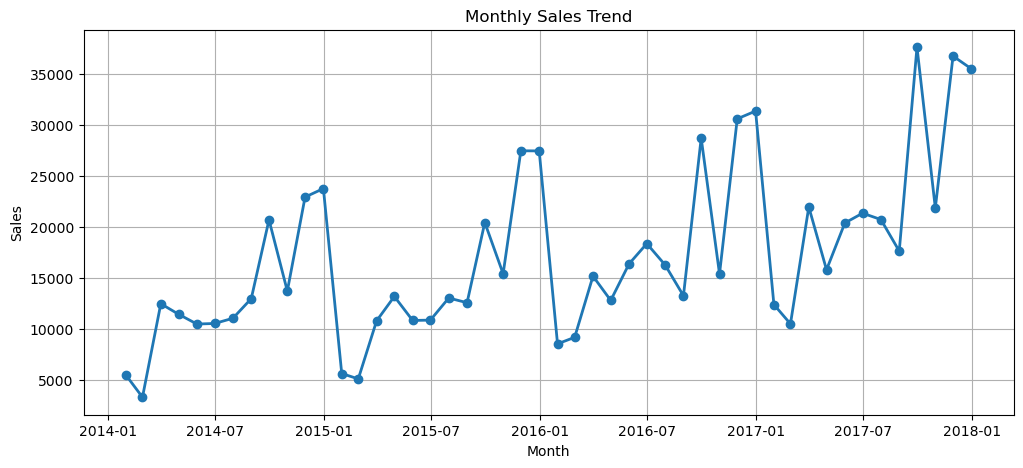

In [23]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales,
         marker='o',
         linewidth=2)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Insight

The monthly sales trend reveals fluctuations in sales throughout the year, highlighting periods of higher and lower business activity.

## Step 5: Time Series Decomposition

Time series decomposition separates sales into three components:

- Trend
- Seasonality
- Residual (Random variation)

This helps understand the underlying behavior of sales over time.

### Code Explanation
- `seasonal_decompose()` separates the time series into different components.
- `period=12` assumes yearly seasonality using monthly data.

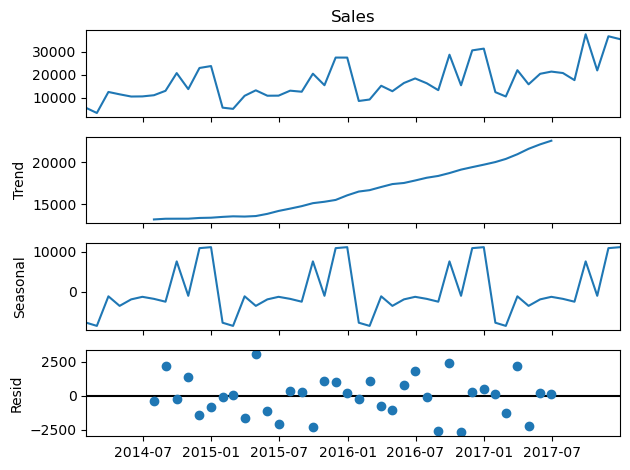

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

decomposition.plot()

plt.show()

### Insight

The decomposition plot helps identify long-term growth trends, seasonal sales patterns, and random fluctuations affecting business performance.

## Step 6: Moving Average

A moving average smooths short-term fluctuations and highlights the overall sales trend.

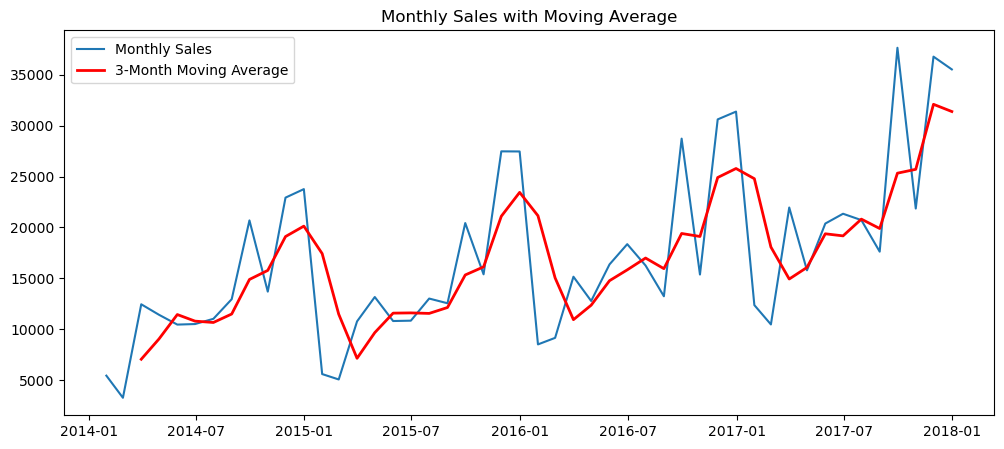

In [25]:
moving_avg = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(12,5))

plt.plot(monthly_sales,label='Monthly Sales')

plt.plot(moving_avg,
         color='red',
         linewidth=2,
         label='3-Month Moving Average')

plt.legend()

plt.title("Monthly Sales with Moving Average")

plt.show()

### Insight

The moving average smooths sudden changes in sales, making it easier to identify the overall direction of business growth.

## Step 7: Simple Sales Forecast

A basic forecast is created using the recent moving average to estimate future monthly sales.

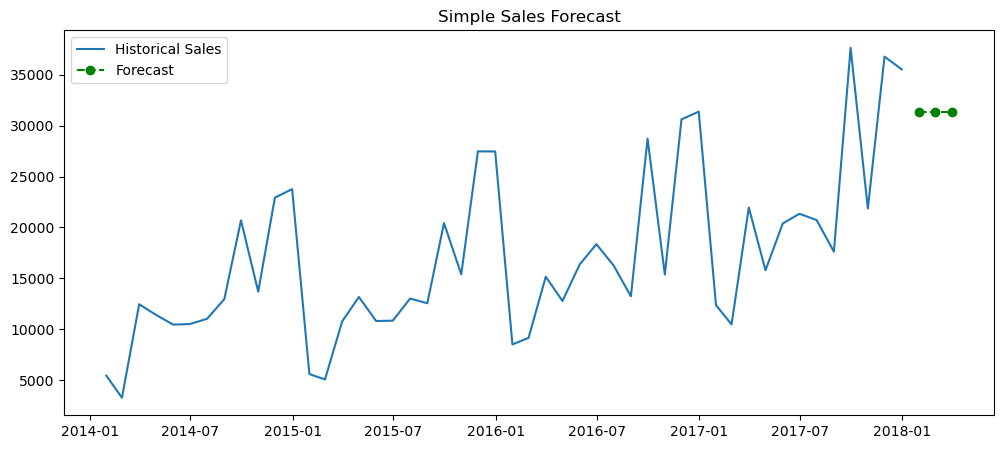

In [26]:
forecast = [moving_avg.iloc[-1]] * 3

forecast_dates = pd.date_range(
    start=monthly_sales.index[-1],
    periods=4,
    freq='M'
)[1:]

forecast_series = pd.Series(
    forecast,
    index=forecast_dates
)

plt.figure(figsize=(12,5))

plt.plot(monthly_sales,label='Historical Sales')

plt.plot(forecast_series,
         color='green',
         linestyle='--',
         marker='o',
         label='Forecast')

plt.legend()

plt.title("Simple Sales Forecast")

plt.show()

### Insight

The forecast provides an estimate of future sales based on recent trends. Although simple, it demonstrates how historical sales data can be used to support business planning and decision-making.

# Customer Segmentation using K-Means Clustering

In this section, K-Means Clustering is used to group similar records based on their purchasing behavior. Before applying the clustering algorithm, the required machine learning libraries are imported.

### Libraries Used

- **StandardScaler** – Standardizes numerical features before clustering.
- **KMeans** – Performs customer segmentation by grouping similar observations.
- **PCA (Principal Component Analysis)** – Reduces data to two dimensions for visualization.

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Step 1: Feature Selection

Before applying K-Means Clustering, the numerical features that represent purchasing behavior are selected.

The following features are used:

- Sales
- Profit
- Quantity
- Discount

These variables help identify patterns and similarities among transactions, allowing the clustering algorithm to group similar records together.

In [28]:
# Select numerical features for clustering

features = df[['Sales', 'Profit', 'Quantity', 'Discount']]

features.head()

,Sales,Profit,Quantity,Discount
Order Date,,,,
2016-11-08,261.960,41.9136,2,0.0
2016-06-12,14.620,6.8714,2,0.0
2015-10-11,22.368,2.5164,2,0.2
2014-06-09,48.860,14.1694,7,0.0
2014-06-09,7.280,1.9656,4,0.0


### Insight

The selected features represent important business metrics that describe customer purchasing behavior. These variables will be used to identify similar groups using the K-Means clustering algorithm.

## Step 2: Feature Scaling

Before applying K-Means Clustering, the selected numerical features are standardized using **StandardScaler**.


In [29]:
# Scale the selected features

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

## Step 3: Verify the Scaled Data

The scaled dataset is converted back into a DataFrame for easier interpretation.

Each feature is now standardized while preserving the original relationships between observations.

In [30]:
import pandas as pd

scaled_df = pd.DataFrame(
    scaled_features,
    columns=features.columns
)

scaled_df.head()

,Sales,Profit,Quantity,Discount
0,1.482788,0.626027,-0.755493,-0.745116
1,-0.686126,-0.088197,-0.755493,-0.745116
2,-0.618184,-0.176960,-0.755493,0.200425
3,-0.385877,0.060549,1.592820,-0.745116
4,-0.750490,-0.188186,0.183832,-0.745116


### Insight

The numerical features have been successfully standardized. All variables are now on a comparable scale, ensuring that no single feature dominates the K-Means clustering algorithm.

## Step 4: Determine the Optimal Number of Clusters (Elbow Method)

The Elbow Method is used to determine the optimal number of clusters (K) for the K-Means algorithm.

### Why is this important?

K-Means requires the number of clusters to be specified before training. Instead of choosing K randomly, the Elbow Method evaluates different values of K and measures the clustering quality using inertia.

### Inertia

Inertia measures the total distance between data points and their assigned cluster centers.

- Lower inertia indicates better clustering.
- The optimal K is selected where the reduction in inertia begins to slow down, forming an "elbow" in the graph.

In [31]:
# Find the optimal number of clusters using the Elbow Method

inertia = []

K = range(1, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_features)
    inertia.append(model.inertia_)

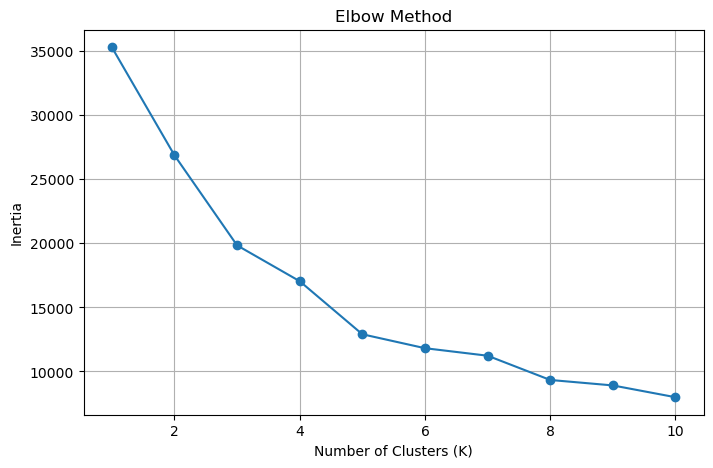

In [32]:
plt.figure(figsize=(8,5))

plt.plot(K,
         inertia,
         marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

### Insight

The Elbow Method graph illustrates how inertia decreases as the number of clusters increases. The optimal value of K is identified at the point where the curve begins to flatten, indicating that adding more clusters provides only a small improvement in clustering quality.

## Building the K-Means Clustering Model

Using the optimal number of clusters identified from the Elbow Method (K = 5), a K-Means model is trained on the standardized customer data.

The model assigns every customer to one of five clusters based on similarities in their purchasing behavior.

In [33]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
features = df[['Sales', 'Profit', 'Quantity', 'Discount']]

# Scale the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [34]:
# Build K-Means Model

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(scaled_data)

df.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Cluster
Order Date,,,,,,,,,,,,,,,,,,,,,
2016-11-08,1,CA-2016-152156,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136,3
2016-06-12,3,CA-2016-138688,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714,1
2015-10-11,5,US-2015-108966,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164,1
2014-06-09,6,CA-2014-115812,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,...,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694,4
2014-06-09,7,CA-2014-115812,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,...,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656,1


## Step 5: Visualizing Customer Clusters using PCA

The clustering model groups customers using multiple numerical features. Since these features exist in a higher-dimensional space, Principal Component Analysis (PCA) is used to reduce them into two principal components.

This allows the clusters to be visualized on a two-dimensional graph while preserving most of the important information from the original dataset.

In [35]:
from sklearn.decomposition import PCA

In [36]:
# Reduce dimensions to 2

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [37]:
print(df.shape)
print(pca_data.shape)

(8827, 21)
(8827, 2)


In [38]:
# Reset the DataFrame index
df = df.reset_index(drop=True)

# Create a new DataFrame using PCA results
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

# Add the Cluster column
pca_df["Cluster"] = df["Cluster"].values

# Display the first 5 rows
pca_df.head()


,PC1,PC2,Cluster
0,1.276897,-0.173560,3
1,-0.029444,-1.203899,1
2,-0.631923,-0.764993,1
3,0.672319,0.639731,4
4,0.073971,-0.538748,1


## Step 6: Visualizing Customer Clusters

After reducing the dataset to two principal components using PCA, the customer clusters are visualized using a scatter plot.

### Why visualize clusters?

Visualizing the clusters helps us:

- Observe how customers are grouped.
- Identify similarities and differences among clusters.
- Evaluate whether the clustering algorithm has successfully separated different customer segments.

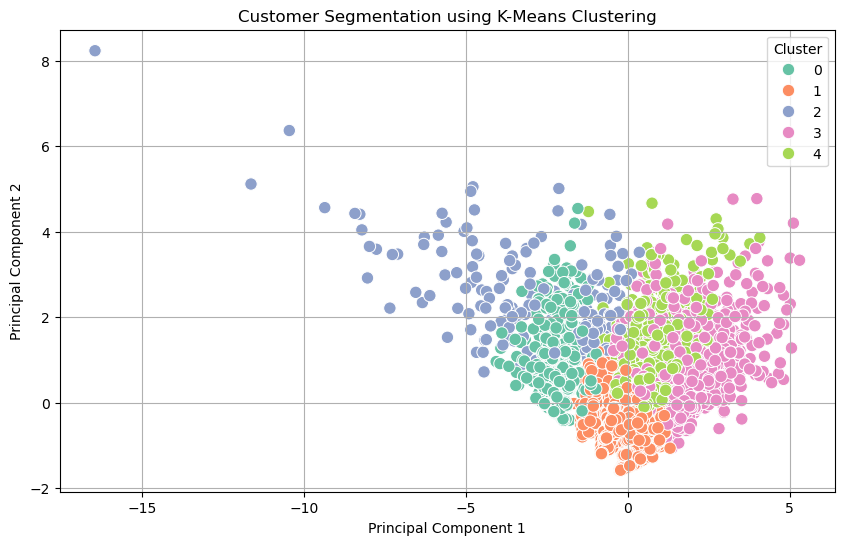

In [39]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segmentation using K-Means Clustering")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.grid(True)

plt.show()


## Cluster Profile Visualization

The bar chart compares the average Sales, Profit, Quantity, and Discount across all customer clusters.

This visualization makes it easier to identify the strengths and characteristics of each customer segment.

In [40]:
cluster_profile = df.groupby("Cluster")[["Sales","Profit","Quantity","Discount"]].mean()

cluster_profile

,Sales,Profit,Quantity,Discount
Cluster,,,,
0,24.234368,-19.505384,3.715698,0.699197
1,47.341469,8.604836,2.457445,0.095802
2,302.418524,-185.740049,4.045455,0.504899
3,306.518443,60.934195,3.944012,0.087745
4,68.879128,18.470783,6.514370,0.088035


In [41]:
cluster_profile = cluster_profile.round(2)

cluster_profile

,Sales,Profit,Quantity,Discount
Cluster,,,,
0,24.23,-19.51,3.72,0.70
1,47.34,8.60,2.46,0.10
2,302.42,-185.74,4.05,0.50
3,306.52,60.93,3.94,0.09
4,68.88,18.47,6.51,0.09


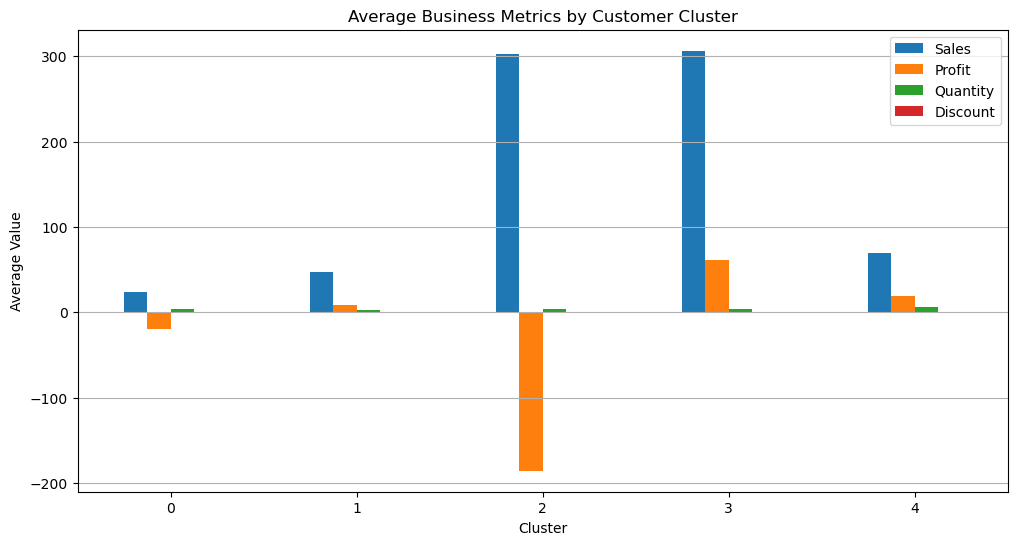

In [42]:
cluster_profile.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Average Business Metrics by Customer Cluster")

plt.ylabel("Average Value")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

### Insights

- **Cluster 3** generated the highest average sales (306.52) and the highest average profit (60.93), making it the most valuable customer segment.

- **Cluster 2** also recorded high average sales (302.42), but experienced the largest average loss (-185.74) because of relatively higher discounts (0.50).

- **Cluster 4** purchased the highest average quantity (6.51) while maintaining a positive profit (18.47), indicating customers who buy more items per order.

- **Cluster 0** had the lowest average sales (24.23) and negative profit (-19.51) with the highest average discount (0.70), suggesting that excessive discounts reduced profitability.

- **Cluster 1** showed moderate sales (47.34), positive profit (8.60), and low discounts (0.10), representing balanced customer behavior.

### Business Recommendations

- Focus marketing campaigns on **Cluster 3** customers to maximize revenue and profit.

- Review the discount strategy for **Cluster 2** and **Cluster 0**, as high discounts are negatively impacting profitability.

- Encourage customers in **Cluster 4** through loyalty programs and bundle offers, since they purchase larger quantities.

- Maintain customer engagement for **Cluster 1** to increase their purchase frequency and overall sales.

# Basic Predictive Modeling using Linear Regression

## Objective
The goal of this section is to build a simple machine learning model to predict **Profit** based on business-related features.

### Target Variable
- **Profit**

### Feature Variables
- Sales
- Quantity
- Discount

The dataset is divided into:
- **80% Training Data** – used to train the model.
- **20% Testing Data** – used to evaluate the model's performance on unseen data.

This split helps ensure that the model generalizes well instead of simply memorizing the data.

In [43]:
# Define Features (Independent Variables)
X = df[["Sales", "Quantity", "Discount"]]

# Define Target (Dependent Variable)
y = df["Profit"]

# Display Features
print("Features (X):")
display(X.head())

# Display Target
print("\nTarget (y):")
display(y.head())

Features (X):


,Sales,Quantity,Discount
0,261.960,2,0.0
1,14.620,2,0.0
2,22.368,2,0.2
3,48.860,7,0.0
4,7.280,4,0.0



Target (y):


0    41.9136
1     6.8714
2     2.5164
3    14.1694
4     1.9656
Name: Profit, dtype: float64

## Splitting the Dataset

To evaluate the model fairly, the dataset is divided into training and testing sets.

- **Training Set (80%)**
  - Used to teach the model the relationship between features and profit.

- **Testing Set (20%)**
  - Used to measure how accurately the trained model predicts unseen data.

A random state of **42** is used so that the results remain consistent every time the notebook is executed.

In [44]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Print dataset shapes
print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)
print("Training Target Shape  :", y_train.shape)
print("Testing Target Shape   :", y_test.shape)

Training Feature Shape : (7061, 3)
Testing Feature Shape  : (1766, 3)
Training Target Shape  : (7061,)
Testing Target Shape   : (1766,)


## Insights

- The dataset has been successfully divided into training and testing sets.
- Around **80%** of the observations are used to train the Linear Regression model.
- The remaining **20%** of the observations are reserved for testing the model.
- Keeping separate training and testing datasets helps evaluate the model's ability to make predictions on unseen data and reduces the risk of overfitting.

# Building the Linear Regression Model

## Objective

In this step, we train a **Linear Regression** model using the training dataset.

Linear Regression attempts to learn the relationship between the independent variables:

- Sales
- Quantity
- Discount

and the target variable:

- Profit

Once the model is trained, it can predict the profit for new, unseen data.

In [45]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("✅ Linear Regression Model Trained Successfully!")

✅ Linear Regression Model Trained Successfully!


## Insights

- The Linear Regression model has successfully learned the relationship between the selected features and Profit.
- During training, the model calculates the best-fit line that minimizes prediction errors.
- The trained model is now ready to predict profit for unseen observations.

# Making Predictions

Now that the model has been trained, we use it to predict the Profit values for the testing dataset.

These predicted values will later be compared with the actual Profit values to evaluate the model's performance.

In [46]:
# Predict Profit using the testing data
y_pred = model.predict(X_test)

# Display first 10 predictions
prediction_df = pd.DataFrame({
    "Actual Profit": y_test.values,
    "Predicted Profit": y_pred
})

prediction_df.head(10)

,Actual Profit,Predicted Profit
0,1.6380,19.921274
1,3.8529,-3.201588
2,25.5112,26.477503
3,-14.1960,2.319330
4,17.9592,21.037518
5,5.0112,28.002912
6,4.6284,5.984152
7,0.2353,-3.783430
8,-20.6176,-62.962105
9,15.5250,20.908138


## Insights

- The model has generated predicted Profit values for the testing dataset.
- These predictions represent the model's estimate based on Sales, Quantity, and Discount.
- The next step is to evaluate how close these predicted values are to the actual Profit values using performance metrics.

# Model Evaluation

After training the Linear Regression model, it is important to evaluate its performance.

The following evaluation metrics are used:

- **R² Score** → Measures how well the model explains the variation in the target variable.
- **Mean Absolute Error (MAE)** → Measures the average prediction error.
- **Root Mean Squared Error (RMSE)** → Measures the overall prediction error while giving higher importance to larger errors.

These metrics help determine the accuracy and reliability of the prediction model.

In [47]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("R² Score :", round(r2, 4))
print("MAE      :", round(mae, 2))
print("RMSE     :", round(rmse, 2))

R² Score : 0.249
MAE      : 21.43
RMSE     : 35.46


## Insights

- The Linear Regression model achieved an **R² Score of 0.249**, indicating that approximately **24.9% of the variation in Profit** is explained by the selected features (Sales, Quantity, and Discount).

- The **Mean Absolute Error (MAE)** is **21.43**, which means the model's predictions differ from the actual Profit values by an average of about **21 units**.

- The **Root Mean Squared Error (RMSE)** is **35.46**, indicating the overall prediction error while giving more importance to larger prediction mistakes.

- The relatively low R² score suggests that **Profit is influenced by additional factors** beyond Sales, Quantity, and Discount. Including more relevant features could improve the model's predictive performance.

- Overall, this model provides a basic understanding of the relationship between the selected features and Profit and serves as a good starting point for predictive analysis.

In [48]:
# Feature Importance (Regression Coefficients)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
1,Quantity,1.821364
0,Sales,0.058371
2,Discount,-108.776951


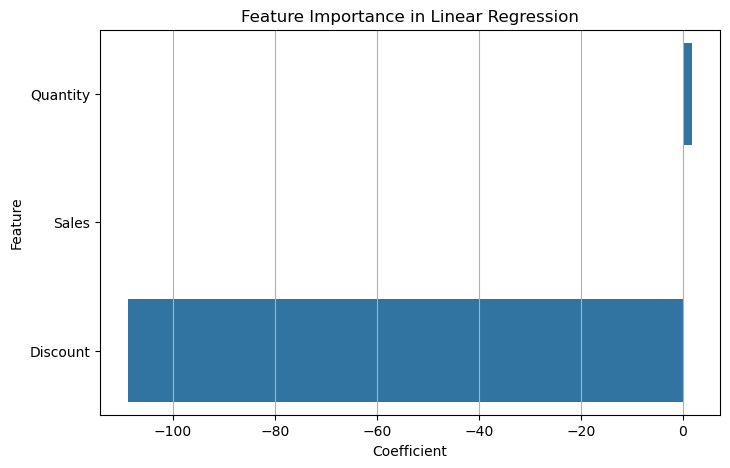

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance in Linear Regression")

plt.xlabel("Coefficient")

plt.ylabel("Feature")

plt.grid(axis="x")

plt.show()

## Insights

- The bar chart clearly shows that **Discount** has the strongest negative effect on Profit.

- **Quantity** has the strongest positive contribution among the selected features.

- **Sales** has only a minor positive effect compared to Quantity.

- Businesses should carefully manage discount strategies, as large discounts may reduce profitability despite increasing sales.